In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import sys

sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/')
from funcs import *
from clean_and_combine import *

import matplotlib.style as mplstyle
mplstyle.use(["ggplot", "fast"])

import warnings
warnings.filterwarnings("ignore")

sys.path.append('/Users/kjesta/Desktop/LABDATA/20cm/')

%load_ext autoreload
%autoreload 2

# Wave analysis
**The measurements were conducted 19.11.25 by Kjersti Stangeland.**

**This notebook analyzes wave gauge measurements of parameters:**

*Wave maker settings*
* 1.1 Hz frequency
* 0.3 V amplitude
* 0.2 m water depth
* 66 periods ran
* 60 second trigger
* NO PLATES, empty tank

*Probe placements*
* $P_0$: 4.864 meters after paddle
* $P_1$: 6.690 meters after paddle
* $P_2$: 7.868 meters after paddle
* $P_3$: 9.148 meters after paddle

*The plates will be placed between 6.336 m - 9.375 m.*

In [2]:
base_path = '/Users/kjesta/Desktop/LABDATA/20cm/f11/a03/'

In [3]:
# For plotting
freq = 1.1 # in Hz
amp = 0.3 # in voltage
depth = 0.20 # in meters

In [4]:
r1_path = os.path.join(base_path, 'f11a03h02r1.csv')
r2_path = os.path.join(base_path, 'f11a03h02r2.csv')
r3_path = os.path.join(base_path, 'f11a03h02r3.csv')

In [5]:
r1_raw = pd.read_csv(r1_path)
r2_raw = pd.read_csv(r2_path)
r3_raw = pd.read_csv(r3_path)

headers = ['time', 'P_0', 'P_1', 'P_2', 'P_3', 'sound_speed']

r1_raw.columns = headers
r2_raw.columns = headers
r3_raw.columns = headers

In [6]:
# Remove noise (probe artefacts) and convert time to seconds
r1_clean = clean(r1_raw)
r2_clean = clean(r2_raw)
r3_clean = clean(r3_raw)

In [7]:
# Apply low-pass filter
r1_filtered = low_pass(r1_clean)
r2_filtered = low_pass(r2_clean)
r3_filtered = low_pass(r3_clean)

In [8]:
# Detrend data
# The probes are not perfectly levelled, causing a linear trend in the data.
# To remove this, we detrend the data by subtracting the mean from each column.
r1 = detrend(r1_filtered)
r2 = detrend(r2_filtered)
r3 = detrend(r3_filtered)

In [9]:
# Checking that all probes now have zero mean (still water level)
for col in ['P_0', 'P_1', 'P_2', 'P_3']:
    print(np.mean(r1[col]), np.mean(r2[col]), np.mean(r3[col]))

-2.0725544829324877e-19 -1.1844747878910786e-19 2.220446049250313e-19
1.9245148770087386e-19 1.480593484863848e-19 5.921189464667502e-20
1.5544158621993658e-19 2.9611869697276965e-20 2.4424906541753445e-19
1.5544158621993658e-19 -1.628652833350233e-19 2.960594732333751e-20


Checking that the pre-processing of the data worked fine.

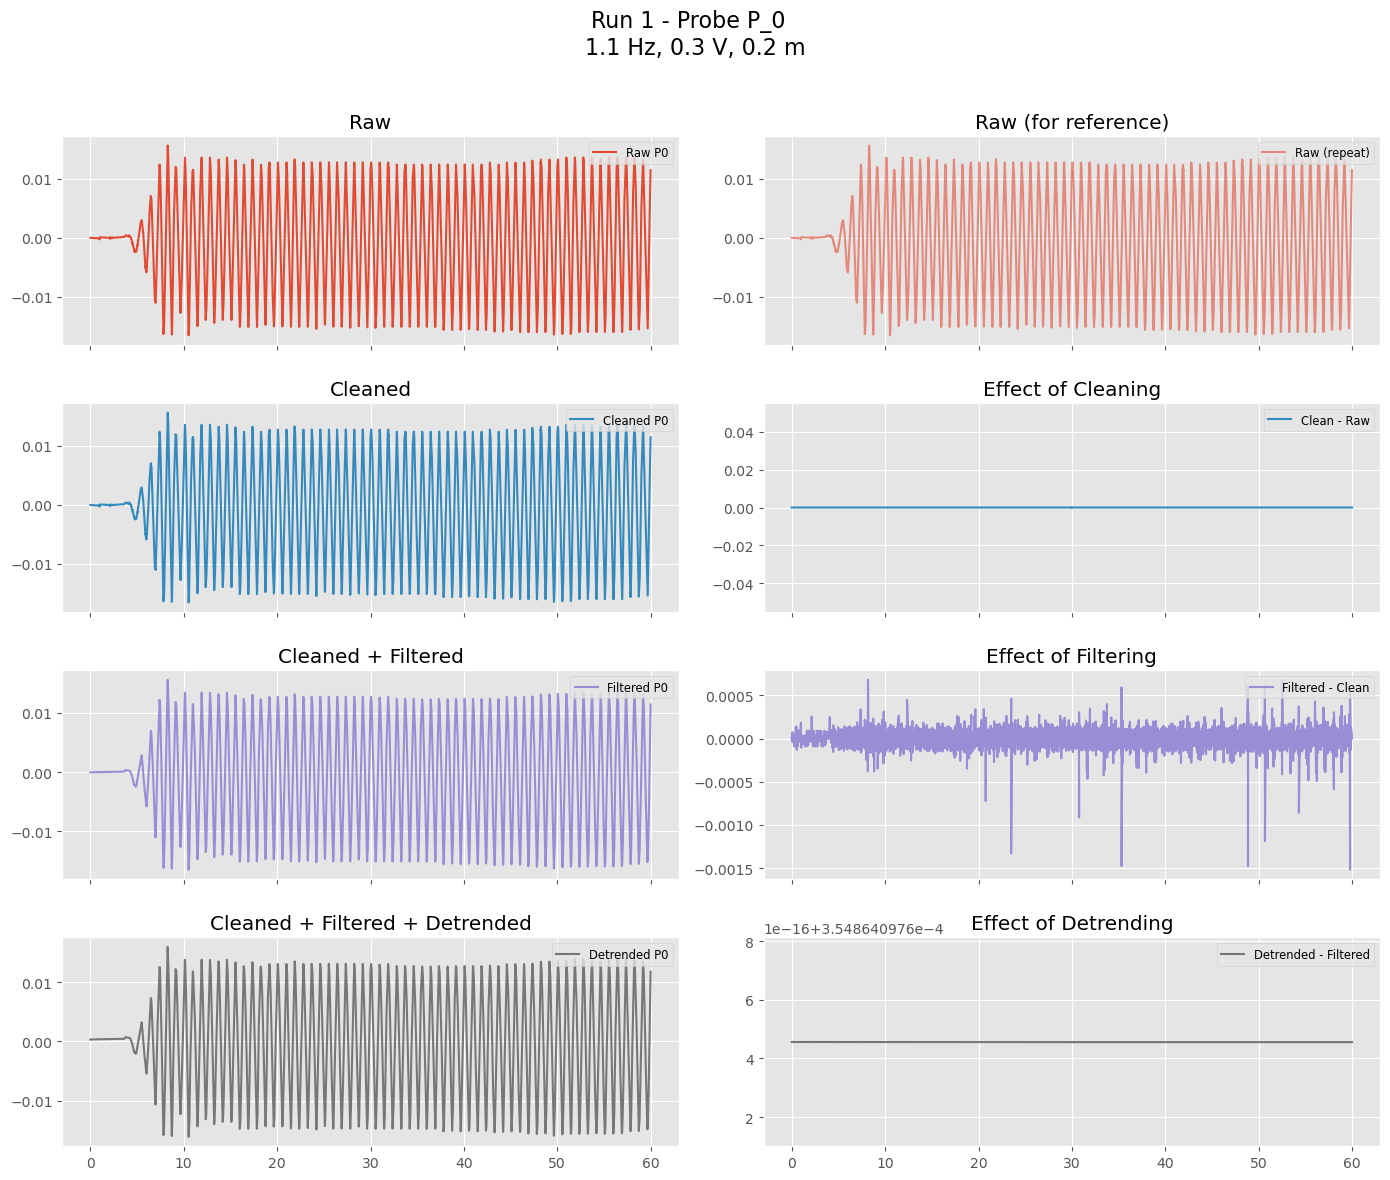

In [103]:
fig, ax = plt.subplots(4, 2, figsize=(14, 12), sharex='col')

ax[0, 0].plot(r1_raw['time'], r1_raw['P_0'], label='Raw P0', color='C0')
ax[1, 0].plot(r1_clean['time'], r1_clean['P_0'], label='Cleaned P0', color='C1')
ax[2, 0].plot(r1_filtered['time'], r1_filtered['P_0'], label='Filtered P0', color='C2')
ax[3, 0].plot(r1['time'], r1['P_0'], label='Detrended P0', color='C3')

ax[0, 0].set_title('Raw')
ax[1, 0].set_title('Cleaned')
ax[2, 0].set_title('Cleaned + Filtered')
ax[3, 0].set_title('Cleaned + Filtered + Detrended')

ax[0, 1].plot(r1_raw['time'], r1_raw['P_0'], label='Raw (repeat)', color='C0', alpha=0.6)
ax[1, 1].plot(r1_clean['time'], r1_clean['P_0'] - r1_raw['P_0'], label='Clean - Raw', color='C1')
ax[2, 1].plot(r1_filtered['time'], r1_filtered['P_0'] - r1_clean['P_0'], label='Filtered - Clean', color='C2')
ax[3, 1].plot(r1['time'], r1['P_0'] - r1_filtered['P_0'], label='Detrended - Filtered', color='C3')

ax[0, 1].set_title('Raw (for reference)')
ax[1, 1].set_title('Effect of Cleaning')
ax[2, 1].set_title('Effect of Filtering')
ax[3, 1].set_title('Effect of Detrending')

for row in range(4):
    for col in range(2):
        ax[row, col].legend(loc='upper right', fontsize='small')

fig.suptitle(f'Run 1 - Probe P_0  \n{freq} Hz, {amp} V, {depth} m', fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.96])

In [11]:
# Positions of probes
x_probe_pos = np.array([4.864, 6.690, 7.868, 9.148])  # Base positions, meters from wave maker

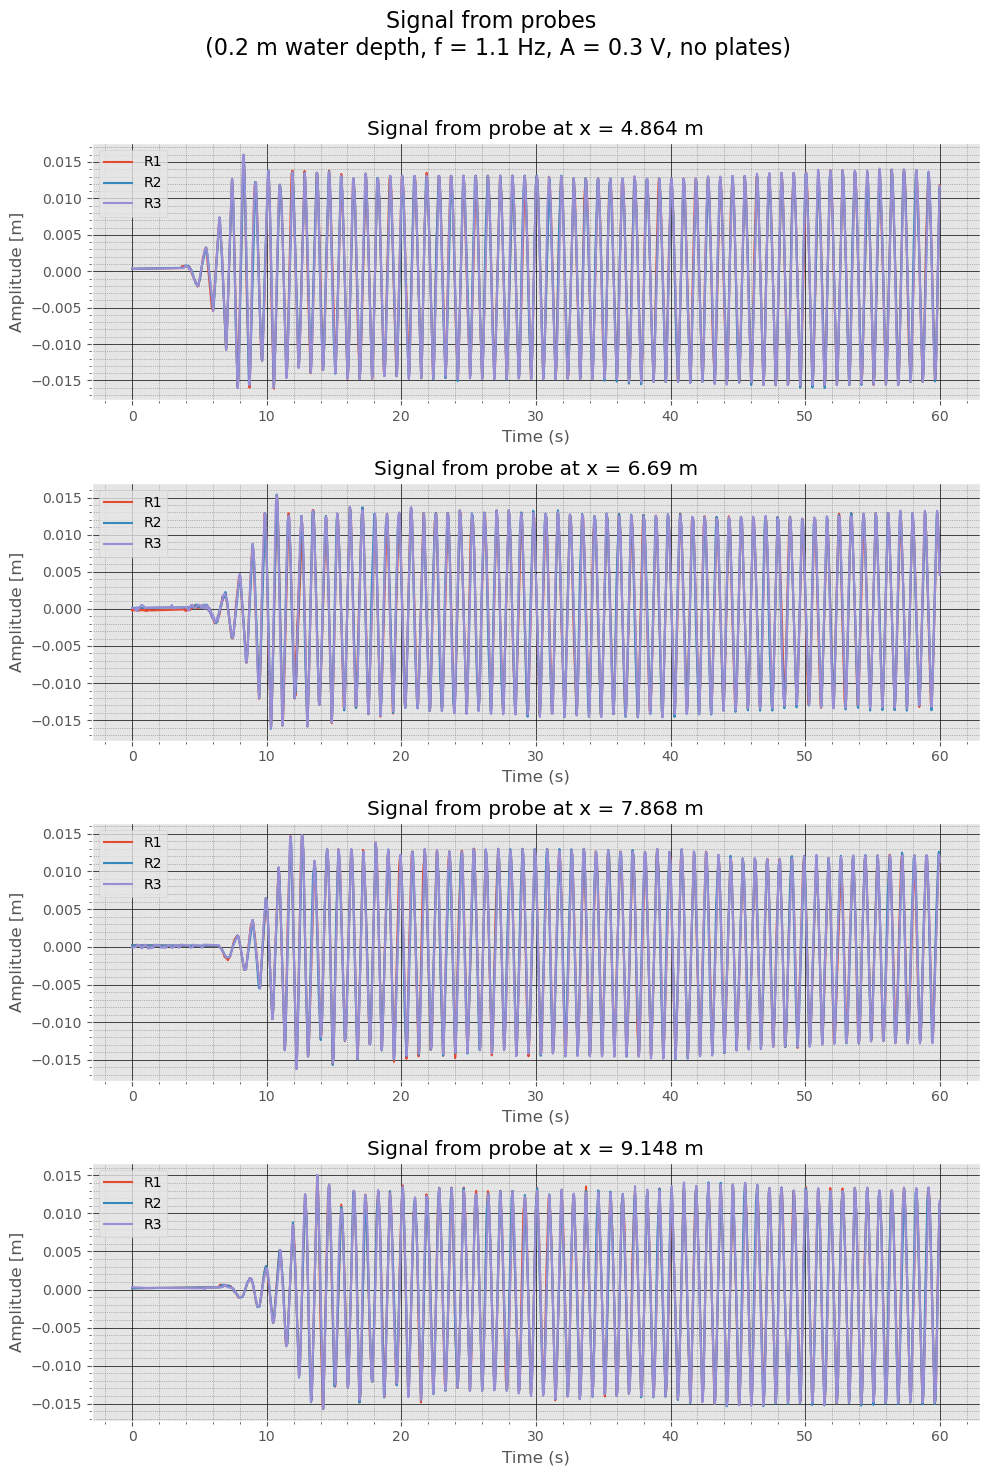

In [12]:
fig, ax = plt.subplots(4,1, figsize=(10, 15))

# P0
ax[0].plot(r1['time'], r1['P_0'], label='R1')
ax[0].plot(r2['time'], r2['P_0'], label='R2')
ax[0].plot(r3['time'], r3['P_0'], label='R3')

# P1
ax[1].plot(r1['time'], r1['P_1'], label='R1')
ax[1].plot(r2['time'], r2['P_1'], label='R2')
ax[1].plot(r3['time'], r3['P_1'], label='R3')

# P2
ax[2].plot(r1['time'], r1['P_2'], label='R1')
ax[2].plot(r2['time'], r2['P_2'], label='R2')
ax[2].plot(r3['time'], r3['P_2'], label='R3')

# P3
ax[3].plot(r1['time'], r1['P_3'], label='R1')
ax[3].plot(r2['time'], r2['P_3'], label='R2')
ax[3].plot(r3['time'], r3['P_3'], label='R3')

for axs in ax:
    axs.grid(which='major', linestyle='-', linewidth='0.5', color='black')
    axs.grid(which='minor', linestyle=':', linewidth='0.5', color='gray')
    axs.legend()
    axs.set_xlabel('Time (s)')
    axs.set_ylabel('Amplitude [m]')
    axs.minorticks_on()

fig.suptitle(f'Signal from probes \n ({depth} m water depth, f = {freq} Hz, A = {amp} V, no plates)', fontsize=16)
ax[0].set_title(f'Signal from probe at x = {x_probe_pos[0]} m')
ax[1].set_title(f'Signal from probe at x = {x_probe_pos[1]} m')
ax[2].set_title(f'Signal from probe at x = {x_probe_pos[2]} m')
ax[3].set_title(f'Signal from probe at x = {x_probe_pos[3]} m')
plt.tight_layout(rect=[0, 0, 1, 0.96])

The wave maker takes some time to build a steady wave train. I therefore cut off the beginning of the time series, absed on what I visually intepret as the steady wave train.

In [13]:
# Cut out transient fronts
wave_maker_build_up_time = 16  # seconds

In [14]:
# ref_cut = ref[ref['time'] >= wave_maker_build_up_time]
r1_cut = r1[r1['time'] >= wave_maker_build_up_time]
r2_cut = r2[r2['time'] >= wave_maker_build_up_time]
r3_cut = r3[r3['time'] >= wave_maker_build_up_time]

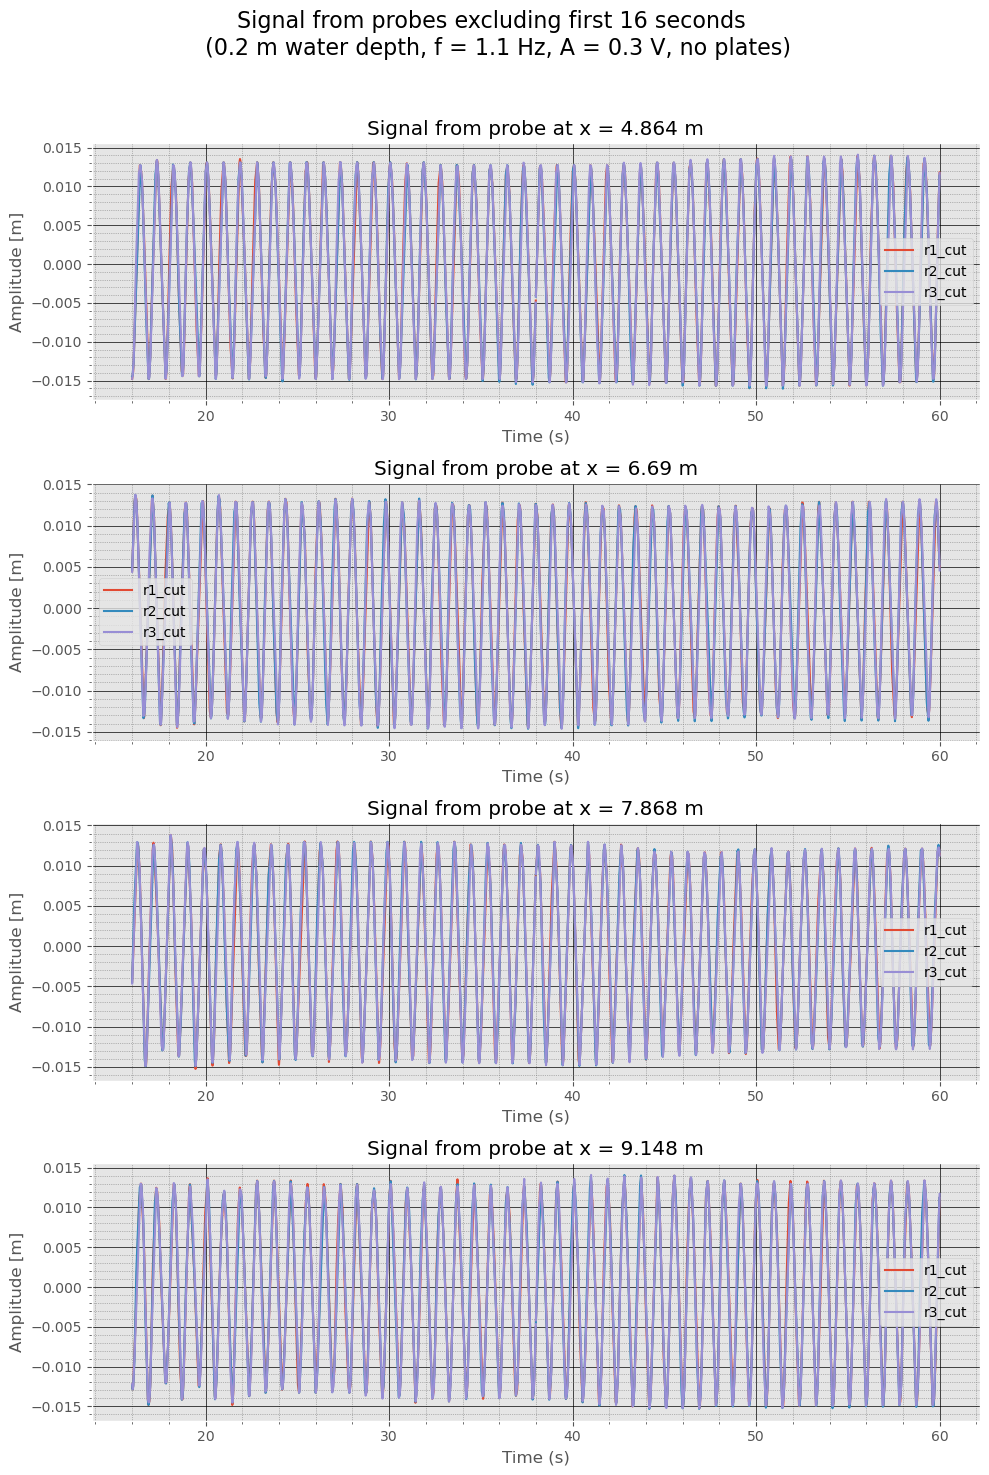

In [15]:
fig, ax = plt.subplots(4,1, figsize=(10, 15))

# P0
ax[0].plot(r1_cut['time'], r1_cut['P_0'], label='r1_cut')
ax[0].plot(r2_cut['time'], r2_cut['P_0'], label='r2_cut')
ax[0].plot(r3_cut['time'], r3_cut['P_0'], label='r3_cut')

# P1
ax[1].plot(r1_cut['time'], r1_cut['P_1'], label='r1_cut')
ax[1].plot(r2_cut['time'], r2_cut['P_1'], label='r2_cut')
ax[1].plot(r3_cut['time'], r3_cut['P_1'], label='r3_cut')

# P2
ax[2].plot(r1_cut['time'], r1_cut['P_2'], label='r1_cut')
ax[2].plot(r2_cut['time'], r2_cut['P_2'], label='r2_cut')
ax[2].plot(r3_cut['time'], r3_cut['P_2'], label='r3_cut')

# P3
ax[3].plot(r1_cut['time'], r1_cut['P_3'], label='r1_cut')
ax[3].plot(r2_cut['time'], r2_cut['P_3'], label='r2_cut')
ax[3].plot(r3_cut['time'], r3_cut['P_3'], label='r3_cut')

for axs in ax:
    axs.grid(which='major', linestyle='-', linewidth='0.5', color='black')
    axs.grid(which='minor', linestyle=':', linewidth='0.5', color='gray')
    axs.legend()
    axs.set_xlabel('Time (s)')
    axs.set_ylabel('Amplitude [m]')
    axs.minorticks_on()

fig.suptitle(f'Signal from probes excluding first {wave_maker_build_up_time} seconds \n ({depth} m water depth, f = {freq} Hz, A = {amp} V, no plates)', fontsize=16)
ax[0].set_title(f'Signal from probe at x = {x_probe_pos[0]} m')
ax[1].set_title(f'Signal from probe at x = {x_probe_pos[1]} m')
ax[2].set_title(f'Signal from probe at x = {x_probe_pos[2]} m')
ax[3].set_title(f'Signal from probe at x = {x_probe_pos[3]} m')
plt.tight_layout(rect=[0, 0, 1, 0.96])

## Plan
* I want to find the observed frequency and wavelength
* Then I can calculate maximum number of waves before reflection, and use that to cut off the end of the time series which may contain reflected waves
* Then I can calculate standard deviation, amplitude ++.

In [102]:
# Finding wavelength and frequency
f_r1 = frequency_analysis(r1_cut)
f_r2 = frequency_analysis(r2_cut)
f_r3 = frequency_analysis(r3_cut)

print(f'Estimated frequency for run 1: Frequency = {f_r1:.2f} Hz')
print(f'Estimated frequency for run 2: Frequency = {f_r2:.2f} Hz')
print(f'Estimated frequency for run 3: Frequency = {f_r3:.2f} Hz')

Estimated frequency for run 1: Frequency = 1.09 Hz
Estimated frequency for run 2: Frequency = 1.09 Hz
Estimated frequency for run 3: Frequency = 1.09 Hz


In [112]:
k_r1 = estimate_wavenumber(f_r1, depth)
k_r2 = estimate_wavenumber(f_r2, depth)
k_r3 = estimate_wavenumber(f_r3, depth)

wl_r1 = 2 * np.pi / k_r1
wl_r2 = 2 * np.pi / k_r2
wl_r3 = 2 * np.pi / k_r3

print(f'Estimated wavelength run1 : {wl_r1}')
print(f'Estimated wavelength run2 : {wl_r2}')
print(f'Estimated wavelength run3 : {wl_r3}')

Estimated wavelength run1 : 1.0790412665265199
Estimated wavelength run2 : 1.078771731688001
Estimated wavelength run3 : 1.0791760304302325


In [118]:
est_max_waves_r1 = max_waves_b4_reflection(25, depth, f_r1, wl_r1, x_probe_pos, wave_maker_build_up_time)
est_max_waves_r2 = max_waves_b4_reflection(25, depth, f_r2, wl_r2, x_probe_pos, wave_maker_build_up_time)
est_max_waves_r3 = max_waves_b4_reflection(25, depth, f_r3, wl_r3, x_probe_pos, wave_maker_build_up_time)

print(f'Estimated maximum number of waves before reflection for run 1: {est_max_waves_r1}')
print(f'Estimated maximum number of waves before reflection for run 2: {est_max_waves_r2}')
print(f'Estimated maximum number of waves before reflection for run 3: {est_max_waves_r3}')

Estimated maximum number of waves before reflection for run 1: [np.float64(19.86819841021657), np.float64(16.483502938671588), np.float64(14.299948028770165), np.float64(11.927324697128558)]
Estimated maximum number of waves before reflection for run 2: [np.float64(19.874339844402304), np.float64(16.488799553837826), np.float64(14.304699629256799), np.float64(11.931484091511717)]
Estimated maximum number of waves before reflection for run 3: [np.float64(19.86512913911384), np.float64(16.480855906693208), np.float64(14.297573394211547), np.float64(11.925246046183942)]
